##1. Imports

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix

##2. Data integration

In [120]:
df1=pd.read_csv("/content/Indian_housing_Delhi_data.csv")
df2=pd.read_csv("/content/Indian_housing_Mumbai_data.csv")
df3=pd.read_csv("/content/Indian_housing_Pune_data.csv")

In [121]:
df = pd.concat([df1, df2, df3], ignore_index=True)

In [122]:
df.shape

(13910, 16)

In [123]:
print("\n=== BASIC STATISTICS ===")
print(df.describe(include='all'))

print("\n=== MISSING VALUES ===")
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== CATEGORICAL VALUES ===")
for col in df.select_dtypes(include=['object']):
        print(f"\n{col}: {df[col].nunique()} unique values")
        print(df[col].value_counts().head(5))


=== BASIC STATISTICS ===
              house_type   house_size location   city      latitude  \
count              13910        13910    13910  13910  13910.000000   
unique                34         1102      702      4           NaN   
top     2 BHK Apartment   5,896 sq ft  Wagholi  Delhi           NaN   
freq                4385          664      743   5000           NaN   
mean                 NaN          NaN      NaN    NaN     22.380579   
std                  NaN          NaN      NaN    NaN      4.660315   
min                  NaN          NaN      NaN    NaN     17.468220   
25%                  NaN          NaN      NaN    NaN     18.611296   
50%                  NaN          NaN      NaN    NaN     19.148081   
75%                  NaN          NaN      NaN    NaN     28.553211   
max                  NaN          NaN      NaN    NaN     31.106586   

           longitude         price currency  numBathrooms  numBalconies  \
count   13910.000000  1.391000e+04    13910  1

In [124]:
df.head()

,house_type,house_size,location,city,latitude,longitude,price,currency,numBathrooms,numBalconies,isNegotiable,priceSqFt,verificationDate,description,SecurityDeposit,Status
0,1 RK Studio Apartment,400 sq ft,Kalkaji,Delhi,28.545561,77.254349,22000,INR,1.0,NaN,NaN,NaN,Posted a day ago,"Fully furnished, loaded with amenities & gadge...",No Deposit,Furnished
1,1 RK Studio Apartment,400 sq ft,Mansarover Garden,Delhi,28.643259,77.132828,20000,INR,1.0,NaN,NaN,NaN,Posted 9 days ago,Here is an excellent 1 BHK Independent Floor a...,No Deposit,Furnished
2,2 BHK Independent Floor,500 sq ft,Uttam Nagar,Delhi,28.618677,77.053352,8500,INR,1.0,NaN,NaN,NaN,Posted 12 days ago,"Zero Brokerage.\n\n2 Room set, Govt bijali Met...",No Deposit,Semi-Furnished
3,3 BHK Independent House,"1,020 sq ft",Model Town,Delhi,28.712898,77.180000,48000,INR,3.0,NaN,NaN,NaN,Posted a year ago,Itâs a 3 bhk independent house situated in M...,No Deposit,Furnished
4,2 BHK Apartment,810 sq ft,Sector 13 Rohini,Delhi,28.723539,77.131424,20000,INR,2.0,NaN,NaN,NaN,Posted a year ago,Well designed 2 bhk multistorey apartment is a...,No Deposit,Unfurnished


##3. Data Preparation

In [125]:
df['Size_split'] = df['house_size'].str.split().str[0]
df['Size_split'] = df['Size_split'].str.replace(',', '', regex=False).astype(int)

df.rename(columns={'Size_split': 'Size_ft²'}, inplace=True)

In [126]:
df['price_inr'] = df['price'].round()

df.drop(columns=['currency','price','house_size','priceSqFt'], inplace=True)

In [128]:
df['Price_per_sqft'] = df['price_inr'] / df['Size_ft²']
df['Price_per_sqft'] = df['Price_per_sqft'].round(1)

In [129]:
df['numBalconies'] = df['numBalconies'].fillna(0).astype(int)

In [130]:
df['SecurityDeposit'] = df['SecurityDeposit'].str.replace(',', '', regex=False)
df['SecurityDeposit'] = df['SecurityDeposit'].str.strip().replace('No Deposit', '0', regex=False).astype(int)

df['SecurityDeposit'] = df['SecurityDeposit'].round()

In [131]:
df['isNegotiable'] = df['isNegotiable'].fillna(0)

df['isNegotiable'] = df['isNegotiable'].replace('Negotiable', 1).astype(int)

/tmp/ipython-input-732/1769977188.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['isNegotiable'] = df['isNegotiable'].replace('Negotiable', 1).astype(int)


In [132]:
le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status'])
df['city'] = le.fit_transform(df['city'])

In [133]:
df['BHK_type'] = df['house_type'].str.split().str[1]
df['BHK'] = df['BHK_type'].map({'RK': 0, 'BHK': 1})
df['rooms_num'] = df['house_type'].str.split().str[0].astype(int)

df.drop(columns=['BHK_type'], inplace=True)

In [134]:
df['property_type'] = df['house_type'].str.split().apply(lambda x: ' '.join(x[2:4]))
df['property_type'].value_counts()
df.drop(columns=['house_type'], inplace=True)

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13910 entries, 0 to 13909
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   location          13910 non-null  object 
 1   city              13910 non-null  int64  
 2   latitude          13910 non-null  float64
 3   longitude         13910 non-null  float64
 4   numBathrooms      13854 non-null  float64
 5   numBalconies      13910 non-null  int64  
 6   isNegotiable      13910 non-null  int64  
 7   verificationDate  13910 non-null  object 
 8   description       13079 non-null  object 
 9   SecurityDeposit   13910 non-null  int64  
 10  Status            13910 non-null  int64  
 11  Size_ft²          13910 non-null  int64  
 12  price_inr         13910 non-null  int64  
 13  Price_per_sqft    13910 non-null  float64
 14  BHK               13910 non-null  int64  
 15  rooms_num         13910 non-null  int64  
 16  property_type     13910 non-null  object

In [137]:
df['numBathrooms'] = df['numBathrooms'].fillna(0).astype(int)

df['location'] = df['location'].map(df['location'].value_counts())

df['property_type'] = le.fit_transform(df['property_type'])

In [139]:
def convert_to_days(time_str):

    time_part = time_str.replace('Posted ', '').replace(' ago', '')

    parts = time_part.split()

    if parts[0] == 'a' or parts[0] == 'an':
        value = 1
        unit = parts[1]
    else:
        value = int(parts[0])
        unit = parts[1]


    if unit == 'minute' or unit == 'minutes':
        return value / (24 * 60)
    elif unit == 'hour' or unit == 'hours':
        return value / 24
    elif unit == 'day' or unit == 'days':
        return value
    elif unit == 'month' or unit == 'months':
        return value * 30
    elif unit == 'year' or unit == 'years':
        return value * 365
    else:
        return np.nan


df['verification_days'] = df['verificationDate'].apply(convert_to_days)
data = np.array(df['verification_days'])

df.drop(columns=['description', 'verificationDate'], inplace=True)

In [140]:
df

,location,city,latitude,longitude,numBathrooms,numBalconies,isNegotiable,SecurityDeposit,Status,Size_ft²,price_inr,Price_per_sqft,BHK,rooms_num,property_type,verification_days
0,27,0,28.545561,77.254349,1,0,0,0,0,400,22000,55.0,0,1,3,1.0
1,9,0,28.643259,77.132828,1,0,0,0,0,400,20000,50.0,0,1,3,9.0
2,75,0,28.618677,77.053352,1,0,0,0,1,500,8500,17.0,1,2,1,12.0
3,9,0,28.712898,77.180000,3,0,0,0,0,1020,48000,47.1,1,3,2,365.0
4,4,0,28.723539,77.131424,2,0,0,0,2,810,20000,24.7,1,2,0,365.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13905,195,3,18.603699,73.761238,1,0,0,36000,2,655,12500,19.1,1,1,0,1095.0
13906,95,3,18.594870,73.798187,2,0,0,50000,2,920,16000,17.4,1,2,0,1095.0
13907,95,3,18.595701,73.797890,1,1,0,35000,0,650,16000,24.6,1,1,0,1095.0
13908,95,3,18.592476,73.798538,2,0,0,60000,0,1200,20000,16.7,1,2,0,1095.0


##4. Feature Discovery for modeling.

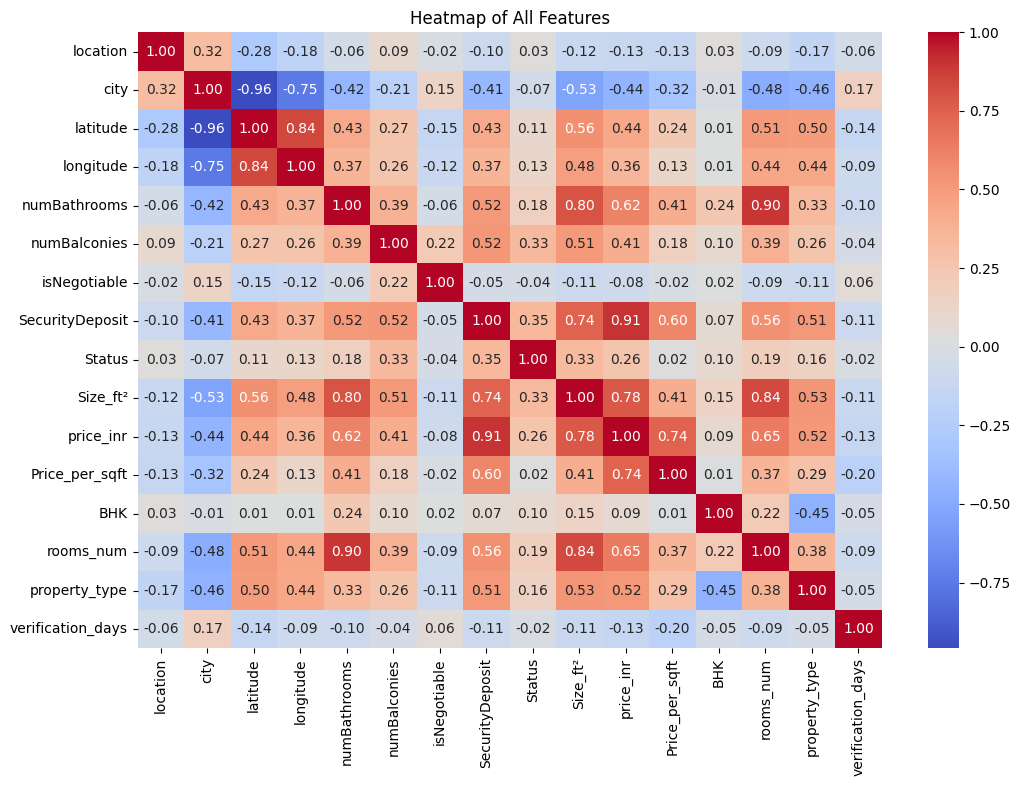

In [145]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap of All Features")
plt.show()

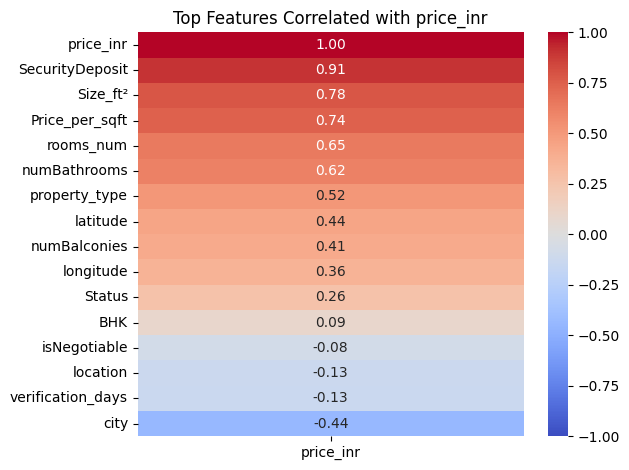

In [146]:
corr = df.corr(numeric_only=True)[['price_inr']].sort_values(by='price_inr', ascending=False)

sns.heatmap(corr.head(22),
            annot=True,
            cmap='coolwarm',
            vmin=-1, vmax=1,
            fmt=".2f")

plt.title("Top Features Correlated with price_inr")
plt.tight_layout()
plt.show()

##5. Data Splitting (Train, Test).

In [147]:
X = df.drop(columns=['price_inr'])
y = df['price_inr']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)